In [14]:
from facenet_pytorch import InceptionResnetV1
import PIL
from torchvision import transforms
from matplotlib import pyplot as plt
import torch
import yaml
import numpy as np

option_path='config.yaml'
with open(option_path,'r') as file_option:
    files_option=yaml.safe_load(file_option)

In [8]:
#проверочка что нахожусь в нужно окружении
# import sys
# print(sys.executable)

In [8]:
def img2tensor(img):
    trans=transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor()
    ])
    tensor=trans(img)
    return tensor

In [24]:
embeder=InceptionResnetV1(pretrained='vggface2').eval()

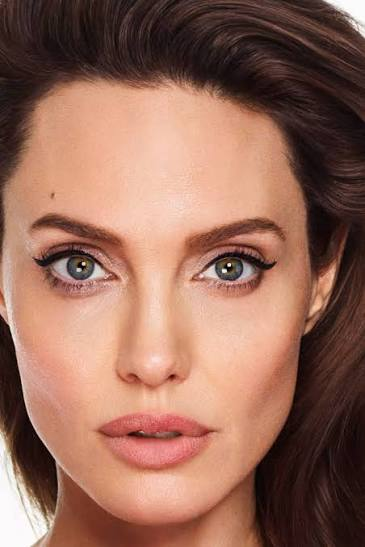

In [25]:
test_img=PIL.Image.open(files_option['test_img_path'])
test_img

In [26]:
test_tensor=img2tensor(test_img)
test_tensor

tensor([[[0.3608, 0.2902, 0.2863,  ..., 0.9843, 0.9843, 0.9843],
         [0.3922, 0.3020, 0.2863,  ..., 0.9843, 0.9843, 0.9843],
         [0.3020, 0.2745, 0.2824,  ..., 0.9843, 0.9843, 0.9843],
         ...,
         [0.9882, 0.9882, 0.9882,  ..., 0.1333, 0.1373, 0.1451],
         [0.9882, 0.9882, 0.9882,  ..., 0.1373, 0.1451, 0.1451],
         [0.9882, 0.9882, 0.9882,  ..., 0.1412, 0.1569, 0.1529]],

        [[0.2627, 0.1922, 0.1882,  ..., 0.9843, 0.9843, 0.9843],
         [0.2941, 0.2039, 0.1882,  ..., 0.9843, 0.9843, 0.9843],
         [0.2039, 0.1765, 0.1843,  ..., 0.9843, 0.9843, 0.9843],
         ...,
         [0.9804, 0.9804, 0.9804,  ..., 0.0549, 0.0588, 0.0667],
         [0.9804, 0.9804, 0.9804,  ..., 0.0588, 0.0667, 0.0667],
         [0.9804, 0.9804, 0.9804,  ..., 0.0627, 0.0745, 0.0706]],

        [[0.2471, 0.1765, 0.1725,  ..., 0.9843, 0.9843, 0.9843],
         [0.2784, 0.1882, 0.1725,  ..., 0.9843, 0.9843, 0.9843],
         [0.1882, 0.1608, 0.1686,  ..., 0.9843, 0.9843, 0.

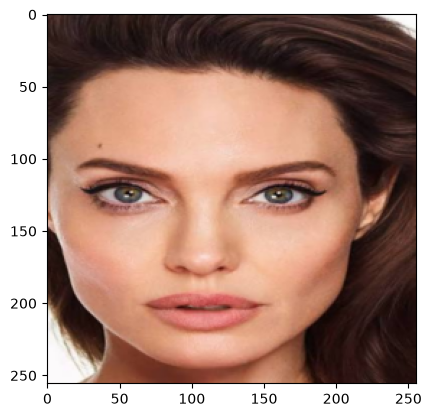

In [27]:
plt.imshow(test_tensor.permute(1,2,0).numpy())

In [33]:
pred=embeder(test_tensor.unsqueeze(0))

In [34]:
pred.shape

torch.Size([1, 512])